# Wind Turbine Regression Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete, reproducible, and academically rigorous regression experiment for the Wind Turbine dataset. It is prepared for direct use in **Chapter 7: Experiments and Results** of the thesis.

The experiment evaluates:

1. Baseline machine learning regressors
2. Repository-supported COBRA regression models
3. KFCProcedure regression models

Because this is a regression task, `CombinedClassifier` is documented as **not applicable** and is not used for model training. The regression-appropriate COBRA models used are `GradientCOBRA` and `MixCOBRARegressor`.

## 1. Objective

### Purpose

The purpose of this experiment is to evaluate whether COBRA-based prediction aggregation and KFCProcedure clusterwise learning improve or change regression performance on the Wind Turbine dataset compared with standard regression baselines.

### Research Questions

1. How do baseline regression models perform on the Wind Turbine power prediction task?
2. How do repository-supported COBRA regression models compare with the baseline regressors?
3. How do KFCProcedure regression models compare with baseline and COBRA regression models?
4. Are the observed results stable across repeated train-test splits?

### Expected Evaluation

The task is regression. Therefore, the experiment uses the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The repeated evaluation uses:

```python
SEEDS = [42, 52, 62, 72, 82]
```

## 2. Dataset Description

### 2.1 Dataset Overview

The dataset is the Kaggle Wind Turbine SCADA dataset, as used in the repository Wind Turbine regression notebook.

Repository-observed dataset source:

```text
berkerisen/wind-turbine-scada-dataset
```

Repository-observed file:

```text
T1.csv
```

The dataset contains wind turbine SCADA measurements recorded over time.

### 2.2 Feature Description

Observable columns from the repository notebook include:

- `Date/Time`
- `LV ActivePower (kW)`
- `Wind Speed (m/s)`
- `Theoretical_Power_Curve (KWh)`
- `Wind Direction (°)`

### 2.3 Target Variable

The target variable is:

```text
LV ActivePower (kW)
```

All remaining columns are treated as input features, consistent with the repository notebook.

## 3. Import Libraries and Repository Modules

The notebook uses `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`, and repository modules from `kfc_procedure`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

### 3.1 Repository Import Configuration

The following cell imports repository classes. If the package is not installed, it searches upward for a local `src/kfc_procedure` directory.

In [2]:
def find_repo_root(start_path=None):
    """Locate repository root containing src/kfc_procedure."""
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )

try:
    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCRegressor
    print("Repository classes imported from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))
    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCRegressor
    print(f"Repository classes imported from source path: {repo_root / 'src'}")

Repository classes imported from installed environment.


## 4. Environment Configuration

Recording package versions supports reproducibility.

In [3]:
environment_table = pd.DataFrame({
    "Component": ["Python", "Platform", "NumPy", "Pandas", "Scikit-learn"],
    "Version": [platform.python_version(), platform.platform(), np.__version__, pd.__version__, sklearn.__version__],
})

environment_table

,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


## 5. Load Dataset

The dataset is loaded from Kaggle using `kagglehub`, following the repository Wind Turbine notebook.

In [4]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

DATASET_ID = "berkerisen/wind-turbine-scada-dataset"
DATASET_FILE = "T1.csv"

dataset_path = dataset_download(DATASET_ID)
print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

df_raw = pd.read_csv(os.path.join(dataset_path, DATASET_FILE))
df_raw.head()

Dataset path: /Users/ougi/.cache/kagglehub/datasets/berkerisen/wind-turbine-scada-dataset/versions/3
Files: ['T1.csv']


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## 6. Exploratory Data Analysis (EDA)

The EDA includes dataset shape, data types, missing values, duplicate count, target distribution, feature statistics, correlation analysis, and additional visualizations.

### 6.1 Dataset Shape

In [5]:
print("Raw dataset shape:", df_raw.shape)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

Raw dataset shape: (50530, 5)
Rows: 50530
Columns: 5


### 6.2 Data Types

In [6]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

data_types_table

,Feature,Data Type
0,Date/Time,str
1,LV ActivePower (kW),float64
2,Wind Speed (m/s),float64
3,Theoretical_Power_Curve (KWh),float64
4,Wind Direction (°),float64


### 6.3 Missing Value Analysis

Missing values are checked using `df.isnull().sum()`. The repository notebook shows no missing values for the original Wind Turbine dataset; this cell recomputes the check directly from the loaded data.

In [7]:
missing_values_table = df_raw.isnull().sum().reset_index()
missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = missing_values_table["Missing Values"] / len(df_raw) * 100
missing_values_table

,Feature,Missing Values,Missing Percentage
0,Date/Time,0,0.0
1,LV ActivePower (kW),0,0.0
2,Wind Speed (m/s),0,0.0
3,Theoretical_Power_Curve (KWh),0,0.0
4,Wind Direction (°),0,0.0


### 6.4 Duplicate Analysis

Duplicate rows are inspected using `df.duplicated().sum()`. Duplicate removal is not observable from the provided Wind Turbine notebook.

In [8]:
duplicate_count = int(df_raw.duplicated().sum())
print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df_raw) * 100, 4), "%")

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


### 6.5 Target Distribution

Since this is a regression task, the target distribution is visualized as a histogram.

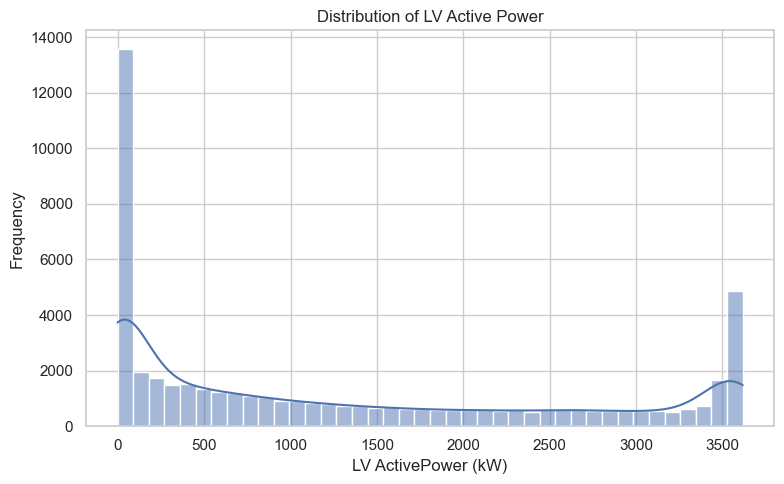

In [9]:
target = "LV ActivePower (kW)"

plt.figure(figsize=(8, 5))
sns.histplot(df_raw[target], bins=40, kde=True)
plt.title("Distribution of LV Active Power")
plt.xlabel("LV ActivePower (kW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 6.6 Feature Statistics

In [10]:
feature_statistics_table = df_raw.describe().T
feature_statistics_table

,count,mean,std,min,25%,50%,75%,max
LV ActivePower (kW),50530.0,1307.684332,1312.459242,-2.471405,50.677890,825.838074,2482.507568,3618.732910
Wind Speed (m/s),50530.0,7.557952,4.227166,0.000000,4.201395,7.104594,10.300020,25.206011
Theoretical_Power_Curve (KWh),50530.0,1492.175463,1368.018238,0.000000,161.328167,1063.776283,2964.972462,3600.000000
Wind Direction (°),50530.0,123.687559,93.443736,0.000000,49.315437,73.712978,201.696720,359.997589


### 6.7 Correlation Analysis

The correlation matrix is computed for numerical columns only.

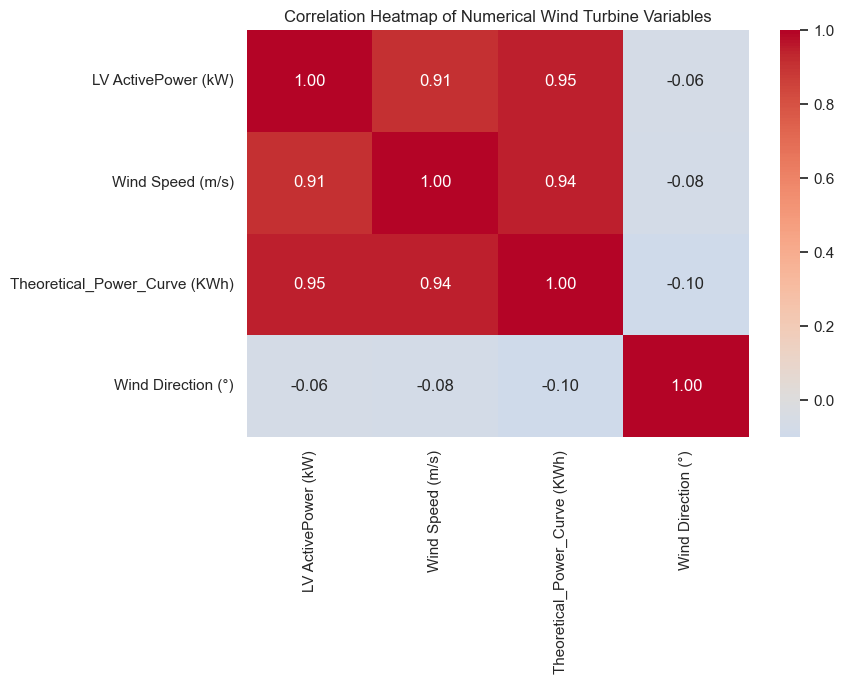

In [11]:
numeric_corr = df_raw.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Wind Turbine Variables")
plt.tight_layout()
plt.show()

### 6.8 Additional Visualizations

The following visualizations are exploratory only and are not used as feature selection rules.

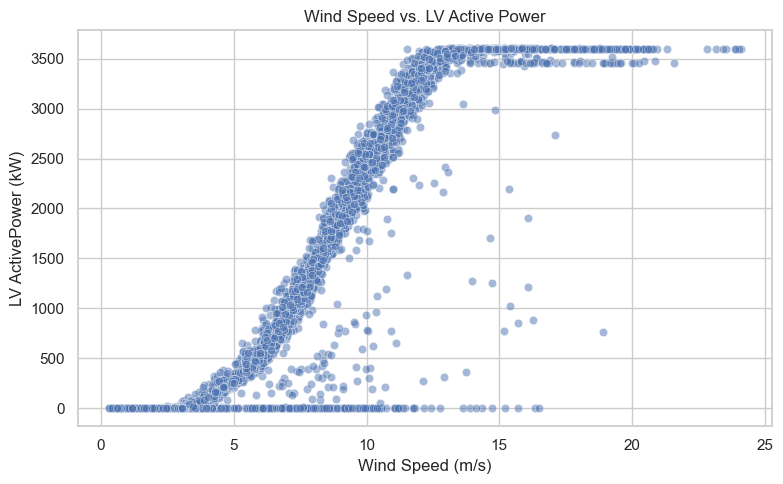

In [12]:
plot_sample = df_raw.sample(min(len(df_raw), 5000), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x="Wind Speed (m/s)",
    y=target,
    alpha=0.5,
)
plt.title("Wind Speed vs. LV Active Power")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("LV ActivePower (kW)")
plt.tight_layout()
plt.show()

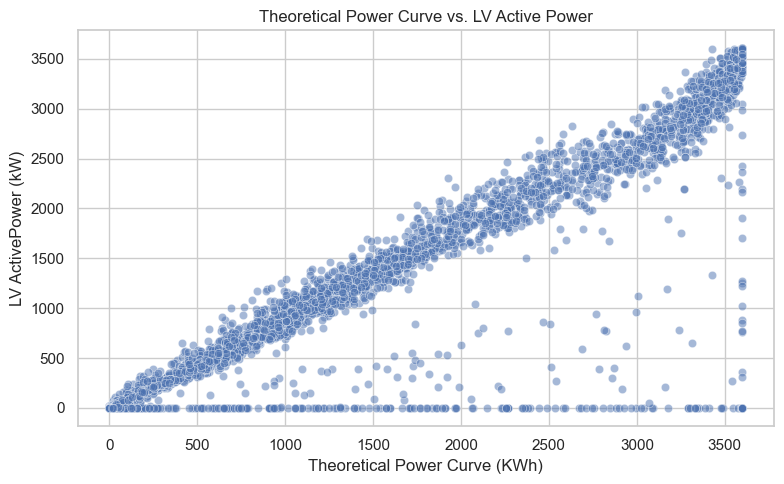

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x="Theoretical_Power_Curve (KWh)",
    y=target,
    alpha=0.5,
)
plt.title("Theoretical Power Curve vs. LV Active Power")
plt.xlabel("Theoretical Power Curve (KWh)")
plt.ylabel("LV ActivePower (kW)")
plt.tight_layout()
plt.show()

## 7. Data Cleaning

### 7.1 Missing Value Handling

Missing values are handled through scikit-learn preprocessing pipelines:

- Numerical variables: `SimpleImputer(strategy="median")`
- Categorical variables: `SimpleImputer(strategy="most_frequent")`

The repository notebook also uses these preprocessing components.

### 7.2 Duplicate Removal

Duplicate removal is **not observable from the provided materials** for this Wind Turbine notebook. Duplicate rows are inspected but not removed as an additional unverified intervention.

### 7.3 Outlier Inspection

Outlier removal is **not observable from the provided materials**. No outlier-based filtering is applied.

### 7.4 Data Consistency Checks

The notebook verifies that the target column exists and is numeric.

In [14]:
df = df_raw.copy()

if target not in df.columns:
    raise ValueError(f"Target column {target} not found.")

if not pd.api.types.is_numeric_dtype(df[target]):
    raise TypeError("The target variable must be numeric for regression.")

print("Target column:", target)
print("Target dtype:", df[target].dtype)
print("Missing values total:", int(df.isnull().sum().sum()))
print("Duplicate removal: Not observable from the provided materials; rows retained.")
print("Outlier removal: Not observable from the provided materials; no filtering applied.")

Target column: LV ActivePower (kW)
Target dtype: float64
Missing values total: 0
Duplicate removal: Not observable from the provided materials; rows retained.
Outlier removal: Not observable from the provided materials; no filtering applied.


## 8. Data Preprocessing

### 8.1 Feature Encoding

The repository notebook treats the object column `Date/Time` as a categorical column and applies `OneHotEncoder(handle_unknown="ignore")`.

### 8.2 Feature Scaling

The preprocessing pipeline uses:

- `StandardScaler` for numerical variables
- `OneHotEncoder(handle_unknown="ignore")` for categorical variables

For KFCProcedure, the preprocessed feature matrix is additionally scaled using `MinMaxScaler(feature_range=(0.05, 0.95))`. This keeps transformed values inside the positive interval required by log-based Bregman divergences such as GKL and Itakura-Saito.

### 8.3 Feature Selection

Feature selection is **not observable from the provided materials**. All columns except the target are used.

### 8.4 Final Feature Matrix

The feature matrix is `X`; the target vector is `y`.

In [ ]:
X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

X shape: (50530, 4)
y shape: (50530,)
Categorical columns: ['Date/Time']
Numerical columns: ['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']


In [16]:
def make_one_hot_encoder():
    """Create OneHotEncoder with compatibility across scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")


def make_preprocessor():
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])


def to_dense_if_sparse(X_matrix):
    """
    Convert sparse matrices to dense arrays for repository components that expect NumPy arrays.

    Note: With one-hot encoded Date/Time, the Wind Turbine dataset can produce a large matrix.
    This conversion follows the repository notebook pattern but may require substantial memory.
    """
    if hasattr(X_matrix, "toarray"):
        return X_matrix.toarray()
    return np.asarray(X_matrix)

## 9. Experimental Setup

### 9.1 Environment Configuration

The software environment was recorded earlier in this notebook.

### 9.2 Random Seed Configuration

```python
SEEDS = [42, 52, 62, 72, 82]
```

### 9.3 Train-Test Split Strategy

Each seed uses `train_test_split` with `test_size=0.2`. Stratification is not used because the target is continuous.

### 9.4 Hyperparameter Configuration

Baseline model families follow the repository Wind Turbine notebook:

- Ridge
- SVR
- Gradient Boosting Regressor
- KNeighborsRegressor

COBRA regression models:

- GradientCOBRA
- MixCOBRARegressor

KFCProcedure regression models:

- KFCRegressor with GradientCOBRA combiner
- KFCRegressor with MixCOBRA combiner

### 9.5 Evaluation Protocol

For every seed, the experiment splits data, fits preprocessing on training data only, trains all models, predicts on the same test split, and stores all metrics in `all_results`.

In [17]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
PRIMARY_METRIC = "RMSE"
KFC_FEATURE_RANGE = (0.05, 0.95)

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("Primary metric:", PRIMARY_METRIC)
print("KFC feature range:", KFC_FEATURE_RANGE)

Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
Primary metric: RMSE
KFC feature range: (0.05, 0.95)


## 10. Evaluation Metrics

### Mean Absolute Error (MAE)

\[
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
\]

Implemented with:

```python
mean_absolute_error(y_true, y_pred)
```

### Mean Squared Error (MSE)

\[
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\]

Implemented with:

```python
mean_squared_error(y_true, y_pred)
```

### Root Mean Squared Error (RMSE)

\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\]

Implemented with:

```python
root_mean_squared_error(y_true, y_pred)
```

### Coefficient of Determination (R²)

\[
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
\]

Implemented with:

```python
r2_score(y_true, y_pred)
```

In [18]:
def evaluate_regression(y_true, y_pred):
    """Evaluate regression predictions using repository-supported metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

## 11. Model Configuration

The following functions define the baseline, COBRA, and KFCProcedure models.

In [19]:
def make_baseline_models(seed):
    """Create baseline regressors observed in the Wind Turbine repository notebook."""
    return {
        "Ridge": Ridge(alpha=1.0),
        "SVR": SVR(),
        "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=seed),
        "KNeighborsRegressor": KNeighborsRegressor(),
    }


def make_gradientcobra(seed):
    """Create repository-supported GradientCOBRA regressor."""
    return GradientCOBRA(
        estimators=[
            "ridge",
            "svr",
            "gradient_boosting_regressor",
            "k_neighbors_regressor",
        ],
        random_state=seed,
    )


def make_mixcobra(seed):
    """Create repository-supported MixCOBRARegressor."""
    return MixCOBRARegressor(
        opt_method="grad",
        optimizer="gd",
        random_state=seed,
    )


def make_kfc_gradientcobra(seed):
    """Create KFCRegressor with GradientCOBRA combiner."""
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="gradientcobra",
        combiner_params={"max_iter": 50},
        n_clusters=3,
        random_state=seed,
    )


def make_kfc_mixcobra(seed):
    """Create KFCRegressor with MixCOBRA combiner."""
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="mixcobra",
        combiner_params={"max_iter": 20},
        n_clusters=3,
        random_state=seed,
    )

## 12. Baseline Models

For each baseline model, the experiment performs:

1. Configuration
2. Training
3. Prediction
4. Evaluation

All baseline models are evaluated on the same seed-specific train-test split.

## 13. COBRA Experiments

### Configuration

The regression-appropriate COBRA models are:

- `GradientCOBRA`
- `MixCOBRARegressor`

### Training, Prediction, and Evaluation

Each COBRA model is trained on the preprocessed training matrix and evaluated on the same test matrix.

### CombinedClassifier

`CombinedClassifier` is **not used** because it is a classification model and the Wind Turbine task has a continuous regression target.

In [20]:
not_applicable_components = pd.DataFrame([
    {
        "Component": "CombinedClassifier",
        "Status": "Excluded",
        "Reason": "Classification model; not appropriate for continuous regression target LV ActivePower (kW).",
    }
])

not_applicable_components

,Component,Status,Reason
0,CombinedClassifier,Excluded,Classification model; not appropriate for cont...


## 14. KFCProcedure Experiments

### Configuration

Two KFCProcedure regression models are evaluated:

1. `KFCRegressor-GradientCOBRA`
2. `KFCRegressor-MixCOBRA`

### K-Step

The K-Step uses divergence-based clustering with:

- Euclidean divergence
- Generalized Kullback-Leibler divergence
- Itakura-Saito divergence

### F-Step

The F-Step uses cluster-wise `linear_regression` local models.

### C-Step

The C-Step aggregates intermediate predictions using either:

- `gradientcobra`
- `mixcobra`

The repository implementation internally splits the training data during KFC fitting: one part is used for K-Step/F-Step learning and another part is used for C-Step aggregation training.

## 15. Repeated Evaluation Function

The following function executes one seed-specific experiment run.

In [21]:
def run_single_seed_experiment(seed, X, y):
    """Run one full seed-specific experiment."""
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=seed,
    )

    preprocessor = make_preprocessor()
    X_train_standard = to_dense_if_sparse(preprocessor.fit_transform(X_train))
    X_test_standard = to_dense_if_sparse(preprocessor.transform(X_test))

    kfc_scaler = MinMaxScaler(feature_range=KFC_FEATURE_RANGE)
    X_train_kfc = kfc_scaler.fit_transform(X_train_standard)
    X_test_kfc = kfc_scaler.transform(X_test_standard)

    seed_results = []

    for model_name, model in make_baseline_models(seed).items():
        start_fit = time.perf_counter()
        model.fit(X_train_standard, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_standard)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    cobra_models = {
        "GradientCOBRA": make_gradientcobra(seed),
        "MixCOBRARegressor": make_mixcobra(seed),
    }

    for model_name, model in cobra_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_standard, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_standard)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    kfc_models = {
        "KFCRegressor-GradientCOBRA": make_kfc_gradientcobra(seed),
        # "KFCRegressor-MixCOBRA": make_kfc_mixcobra(seed),
    }

    for model_name, model in kfc_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_kfc, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_kfc)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    return seed_results

## 16. Execute Repeated Experiment

The required result storage object is:

```python
all_results = []
```

Each row stores:

- model name
- seed
- MAE
- MSE
- RMSE
- R²
- fit time
- prediction time

The Wind Turbine dataset can be computationally expensive when `Date/Time` is one-hot encoded. The notebook keeps this repository-supported preprocessing for consistency.

In [22]:
def run_repeated_experiment(X, y, seeds):
    all_results = []
    for seed in seeds:
        print(f"Running experiment for seed = {seed}")
        all_results.extend(run_single_seed_experiment(seed, X, y))
    return all_results


if __name__ == "__main__":
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table

Running experiment for seed = 42


ValueError: Input y contains NaN.

## 17. Results Summary

### 17.1 Per-Seed Results

The per-seed table reports each model's performance for each seed.

In [ ]:
per_seed_results_table = per_seed_results_table[
    ["Model", "Seed", "MAE", "MSE", "RMSE", "R2", "Fit Time", "Prediction Time"]
].sort_values(["Seed", "Model"]).reset_index(drop=True)

per_seed_results_table

### 17.2 Aggregated Results

The aggregated table reports mean and standard deviation across seeds.

In [ ]:
metric_columns = ["MAE", "MSE", "RMSE", "R2"]

aggregated_results_table = (
    per_seed_results_table
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
    .sort_values(("RMSE", "mean"), ascending=True)
)

aggregated_results_table

### 17.3 Mean ± Standard Deviation

This table formats each metric as `mean ± standard deviation` for thesis reporting.

In [ ]:
def format_mean_std(mean_value, std_value, decimals=3):
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"

formatted_aggregated_results = pd.DataFrame(index=aggregated_results_table.index)

for metric in metric_columns:
    formatted_aggregated_results[metric] = [
        format_mean_std(m, s)
        for m, s in zip(aggregated_results_table[(metric, "mean")], aggregated_results_table[(metric, "std")])
    ]

formatted_aggregated_results = formatted_aggregated_results.reset_index()
formatted_aggregated_results

### 17.4 Model Ranking

Models are ranked by mean RMSE. Lower RMSE indicates better predictive performance.

In [ ]:
ranking_table = (
    aggregated_results_table[(PRIMARY_METRIC, "mean")]
    .reset_index()
    .rename(columns={(PRIMARY_METRIC, "mean"): f"Mean {PRIMARY_METRIC}"})
    .sort_values(f"Mean {PRIMARY_METRIC}", ascending=True)
    .reset_index(drop=True)
)

ranking_table.insert(0, "Rank", ranking_table.index + 1)
ranking_table

### 17.5 Best Model Analysis

In [ ]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_rmse = ranking_table.loc[0, f"Mean {PRIMARY_METRIC}"]

print("Best model by mean RMSE:", best_model_name)
print("Mean RMSE:", round(best_model_rmse, 6))

formatted_aggregated_results[formatted_aggregated_results["Model"] == best_model_name]

## 18. Required Visualizations

The following cells generate the required publication-quality figures:

- Target distribution
- Correlation heatmap
- Model comparison bar chart
- Ranking chart
- Metric comparison chart

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=40, kde=True)
plt.title("Target Distribution: LV Active Power")
plt.xlabel("LV ActivePower (kW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
comparison_plot_data = (
    aggregated_results_table[("RMSE", "mean")]
    .reset_index()
    .rename(columns={("RMSE", "mean"): "Mean RMSE"})
    .sort_values("Mean RMSE", ascending=True)
)

plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_plot_data, x="Mean RMSE", y="Model", orient="h")
plt.title("Model Comparison by Mean RMSE")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 6))
sns.barplot(data=ranking_table, x=f"Mean {PRIMARY_METRIC}", y="Model", orient="h")
plt.title("Model Ranking by Mean RMSE")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
mean_metric_table = per_seed_results_table.groupby("Model")[["MAE", "RMSE", "R2"]].mean().reset_index()
metric_comparison_long = mean_metric_table.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "R2"],
    var_name="Metric",
    value_name="Mean Score",
)

g = sns.catplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    col="Metric",
    kind="bar",
    sharex=False,
    height=5,
    aspect=0.9,
)
g.fig.suptitle("Metric Comparison Across Models", y=1.05)
for ax in g.axes.flat:
    ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## 19. LaTeX-Ready Tables

The following tables are generated from computed results. No performance values are manually inserted.

In [ ]:
latex_per_seed_table = per_seed_results_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Wind Turbine regression results.",
    label="tab:wind_turbine_per_seed_results",
)
print(latex_per_seed_table)

In [ ]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Wind Turbine regression results across five random seeds.",
    label="tab:wind_turbine_aggregated_results",
)
print(latex_aggregated_table)

In [ ]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean RMSE for the Wind Turbine regression experiment.",
    label="tab:wind_turbine_model_ranking",
)
print(latex_ranking_table)

## 20. Discussion

### Comparison of Baselines

The baseline regressors provide the reference point for evaluating COBRA and KFCProcedure models. The comparison should be based on aggregated results rather than a single split.

### Comparison of COBRA Models

The COBRA regression models are `GradientCOBRA` and `MixCOBRARegressor`. `CombinedClassifier` is excluded because it is not applicable to regression.

### Comparison of KFC Models

The KFCProcedure models apply divergence-based clustering, local linear regression, and COBRA-based regression aggregation.

### Strengths

1. The experiment uses repeated evaluation over five seeds.
2. Preprocessing is fitted only on training data.
3. All models are evaluated on the same seed-specific test splits.
4. Mean and standard deviation are reported for every metric.
5. Regression-specific metrics are used consistently.

### Limitations

1. Outlier handling is not applied because it is not observable from the provided materials.
2. Feature selection is not applied because it is not observable from the provided materials.
3. One-hot encoding `Date/Time` may produce a high-dimensional feature matrix and increase computational cost.
4. Hyperparameter search beyond repository-supported configuration is not introduced.
5. The experiment uses repeated hold-out splits rather than nested cross-validation.

### Threats to Validity

1. Model rankings may change under different hyperparameter settings.
2. Treating `Date/Time` as a categorical variable may affect scalability.
3. Results are specific to the selected Wind Turbine dataset and repository implementation.
4. The computational cost of COBRA and KFC components may limit extensive hyperparameter exploration.

In [ ]:
baseline_model_names = [
    "Ridge",
    "SVR",
    "Gradient Boosting Regressor",
    "KNeighborsRegressor",
]

baseline_ranking = ranking_table[ranking_table["Model"].isin(baseline_model_names)].reset_index(drop=True)
cobra_ranking = ranking_table[ranking_table["Model"].isin(["GradientCOBRA", "MixCOBRARegressor"])].reset_index(drop=True)
kfc_ranking = ranking_table[ranking_table["Model"].str.startswith("KFCRegressor")].reset_index(drop=True)

print("Baseline model ranking:")
display(baseline_ranking)

print("COBRA model ranking:")
display(cobra_ranking)

print("KFCProcedure model ranking:")
display(kfc_ranking)

## 21. Conclusion

This notebook implemented a complete Wind Turbine regression experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated baseline regressors, repository-supported COBRA regression models, and KFCProcedure regression models across five repeated train-test splits.

The final interpretation should be based on the generated per-seed, aggregated, and ranking tables. No performance claim should be made without referring to the computed values.

## 22. Reproducibility Checklist

- Dataset source is explicitly stated.
- Target column is explicitly defined.
- Random seeds are fixed.
- Train-test split configuration is fixed.
- Preprocessing is fitted only on training data.
- Missing values are handled using scikit-learn pipelines.
- Per-seed results are stored in `all_results`.
- Mean and standard deviation are reported.
- LaTeX-ready tables are generated from computed results.
- `CombinedClassifier` is explicitly excluded because it is not appropriate for regression.